In [2]:
import decoupler as dc
from scipy.stats import rankdata
import seaborn as sns
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import scanpy as sc
from anndata import AnnData
from scipy.sparse import csr_matrix, issparse
from scipy import sparse
from tqdm.auto import tqdm
from scipy.special import ndtr
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Generate simulated data
!uv run simulated_data_generator.py simulated_data_parameters.json

{'output_dir': 'simulated_data/', 'output_exp_file': 'simulated_scRNASeq_data.tsv', 'output_prior_file': 'simulated_prior_data.tsv', 'output_ground_truth_file': 'simulated_ground_truth.tsv', 'n_cells': 1000, 'n_genes': 1000, 'n_tfs': 100, 'ground_truth_active_inactive_prob': 0.1, 'overlap_alpha_factor': 0, 'average_number_of_targets_per_tf': 30, 'include_tfs_in_expression': False, 'tf_effect_factor': 1, 'missing_percentage': 70, 'weighted': False, 'random_seed': 42}
Generating prior data (Poisson targets)...
Generating gene expression data...
Zero percentage before explicit dropout: 39.57%
Zero percentage after dropout: 81.83709999999999
Wrote prior to simulated_prior_data.tsv
Wrote ground truth to simulated_ground_truth.tsv
Wrote gene expression to simulated_scRNASeq_data.tsv


In [4]:
# Gene Expression data
raw = pd.read_csv("simulated_data/simulated_scRNASeq_data.tsv", sep="\t", index_col=0)
adata = sc.AnnData(csr_matrix(raw.values), var=pd.DataFrame(index=raw.columns), obs=pd.DataFrame(index=raw.index))
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [5]:
# Prior Knowledge Network
net_file = "simulated_data/simulated_prior_data.tsv"
effect_map = {"upregulates-expression": 1, "downregulates-expression": -1}
net = pd.read_csv(net_file, sep="\t", converters={"interaction": effect_map.get}, )
net

,source,target,interaction,weight
0,TF_1,G_135,1,1.0
1,TF_1,G_762,1,1.0
2,TF_1,G_48,1,1.0
3,TF_1,G_962,1,1.0
4,TF_1,G_706,1,1.0
...,...,...,...,...
2964,TF_100,G_861,-1,1.0
2965,TF_100,G_677,-1,1.0
2966,TF_100,G_585,-1,1.0
2967,TF_100,G_641,-1,1.0


In [6]:
ground_truth_df = pd.read_csv("simulated_data/simulated_ground_truth.tsv", sep="\t", index_col=0)

In [7]:
!uv run z-aggregate --dataset simulated_data/simulated_scRNASeq_data.tsv --priors simulated_data/simulated_prior_data.tsv --output results --verbose --min-targets 4 --no-preprocess

2026-01-23 11:50:10 - INFO - Reading expression data from: simulated_data/simulated_scRNASeq_data.tsv
2026-01-23 11:50:10 - INFO -    Loaded data shape: 1000 cells x 1000 genes
2026-01-23 11:50:10 - INFO - Loading prior network from: simulated_data/simulated_prior_data.tsv
2026-01-23 11:50:10 - INFO -    Loaded 2969 interactions. Unique TFs: 100
2026-01-23 11:50:10 - INFO - Computing weights using strategy: Uniform_Weight
2026-01-23 11:50:10 - INFO -    Network Overlap: 2969/2969 edges (100.00%) target genes present in dataset.
2026-01-23 11:50:10 - INFO -    Weights computed successfully.
2026-01-23 11:50:10 - INFO - Saved z-aggregate scores (cells=1000, TFs=100) to results/simulated_scRNASeq_data_z_aggregate_scores.tsv
2026-01-23 11:50:10 - INFO - Saved z-aggregate p-values (cells=1000, TFs=100) to results/simulated_scRNASeq_data_z_aggregate_pvalues.tsv
2026-01-23 11:50:10 - INFO - Saved AnnData object to results/simulated_scRNASeq_data_z_aggregate_results.h5ad. Added .obsm keys: 'z_

In [8]:
z_aggregate_score_df = pd.read_csv("results/simulated_scRNASeq_data_z_aggregate_scores.tsv", sep="\t")
z_aggregate_score_df.head()

,Unnamed: 0,TF_58,TF_80,TF_61,TF_91,TF_95,TF_44,TF_75,TF_2,TF_32,...,TF_94,TF_26,TF_85,TF_90,TF_16,TF_55,TF_86,TF_66,TF_53,TF_33
0,Cell_1,-0.225905,0.286012,11.700451,5.414911,-0.226637,0.624118,2.513273,-0.308835,8.811954,...,1.249651,-0.201829,4.528505,7.206443,2.321845,-0.896234,18.408282,-0.068106,0.178792,-0.222278
1,Cell_2,-0.506777,-2.140261,0.040246,-0.863273,2.152835,-0.787259,-0.427333,-0.283948,0.000914,...,-0.592931,3.105449,1.475056,0.245994,-0.253962,0.222212,9.986486,9.277897,-0.114060,0.709376
2,Cell_3,1.060945,0.671558,-0.323356,-1.537470,-0.597314,0.622905,2.427111,-1.161409,-0.195746,...,1.024611,2.809190,2.751174,0.513827,3.991436,1.453365,-0.183837,-0.114866,1.280170,11.487634
3,Cell_4,5.808464,1.989723,8.411391,3.018262,6.757168,4.550911,0.045448,3.229702,5.285520,...,5.175154,10.363668,2.427708,-0.418218,0.268030,4.925535,0.246665,0.599604,0.266741,10.120764
4,Cell_5,-1.406318,-2.120182,-1.700186,-1.112963,-0.740807,-1.598782,-1.167443,-1.338094,-0.943014,...,-0.990036,-0.864669,-0.847874,-0.788319,-0.545667,-0.683769,-1.089438,-0.111166,-1.904370,-1.367849


In [9]:
# Make network decoupler compatible
net_dc = net.copy()
net_dc["weight"] = net_dc["interaction"] * net_dc["weight"]
net_dc = net_dc[["source", "target", "weight"]]

In [10]:
dc.mt.ulm(adata, net_dc, tmin=0)
dc.mt.mlm(adata, net_dc, tmin=0)
dc.mt.zscore(adata, net_dc, tmin=0)

In [11]:
sc.pp.scale(adata)
dc.mt.viper(adata, net_dc, tmin=0)

## Plot ROC Curves

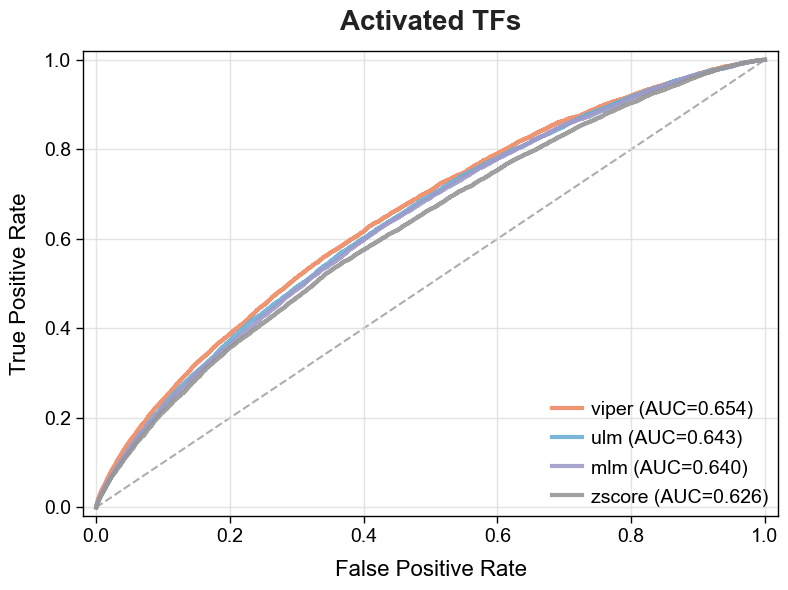

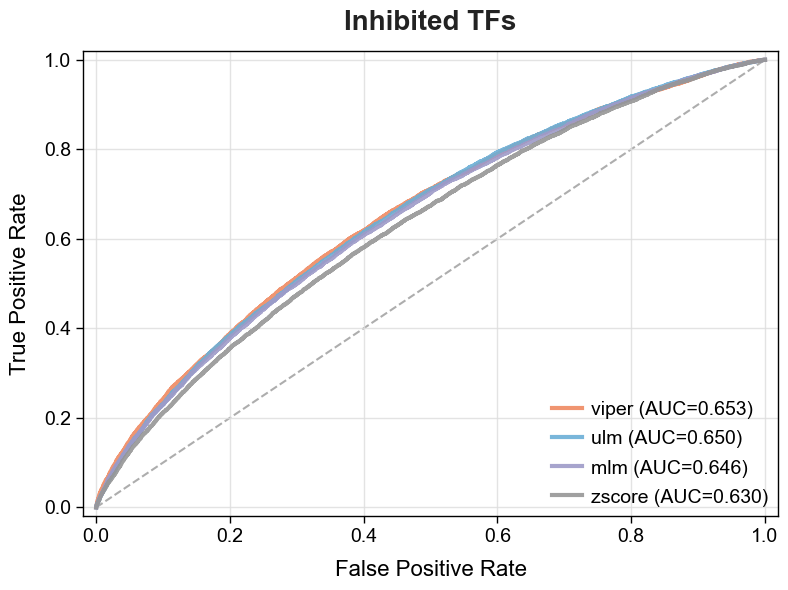

In [12]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import os

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

def plot_custom_benchmarks_paper(adata, ground_truth_df, methods_dict,
                                 text_size=16, filename_prefix=None):
    color_map = {
        "z-aggregate": "#74c476",  # Soft Green
        "ulm": "#6baed6",          # Soft Blue
        "viper": "#ef8a62",        # Salmon/Orange
        "mlm": "#9e9ac8",          # Purple
        "zscore": "#969696"        # Grey
    }

    fallback_palette = sns.color_palette("colorblind", n_colors=10)

    # Define the two tasks
    tasks = [
        {
            "title": "Activated TFs",
            "gt_val": 1,
            "invert_score": False,
            "suffix": "activated"
        },
        {
            "title": "Inhibited TFs",
            "gt_val": -1,
            "invert_score": True,
            "suffix": "inhibited"
        }
    ]

    for task in tasks:
        fig, ax = plt.subplots(figsize=(8, 6), dpi=100)

        # --- Collect Data ---
        roc_data = []
        has_data = False

        for method_name, obsm_key in methods_dict.items():
            if obsm_key not in adata.obsm:
                continue

            scores_df = adata.obsm[obsm_key]
            common_tfs = list(set(ground_truth_df.columns) & set(scores_df.columns))
            common_cells = list(set(ground_truth_df.index) & set(scores_df.index))

            if not common_tfs or not common_cells:
                continue

            # Data prep
            y_true_flat = ground_truth_df.loc[common_cells, common_tfs].values.flatten()
            y_score_flat = scores_df.loc[common_cells, common_tfs].values.flatten()

            # Determine positive class based on task
            if task["gt_val"] == 1:
                y_true_binary = (y_true_flat == 1).astype(int)
            else:
                y_true_binary = (y_true_flat == -1).astype(int)

            if y_true_binary.sum() == 0:
                continue

            has_data = True

            if task["invert_score"]:
                y_score_flat = -y_score_flat

            fpr, tpr, _ = roc_curve(y_true_binary, y_score_flat)
            roc_val = auc(fpr, tpr)

            roc_data.append({
                "name": method_name,
                "fpr": fpr,
                "tpr": tpr,
                "auc": roc_val
            })

        if not has_data:
            plt.close(fig)
            print(f"Skipping {task['title']} - No valid ground truth data found.")
            continue
        # 1. Diagonal random chance line
        ax.plot([0, 1], [0, 1], color='#999999', linestyle='--', lw=1.5, alpha=0.8, zorder=1)

        # 2. Plot Methods
        for i, data in enumerate(roc_data):
            # Determine Color
            c = None
            for key, val in color_map.items():
                if key in data["name"].lower():
                    c = val
                    break
            if c is None:
                c = fallback_palette[i % len(fallback_palette)]

            ax.plot(
                data["fpr"], data["tpr"],
                label=f'{data["name"]} (AUC={data["auc"]:.3f})',
                color=c,
                lw=3.0,
                alpha=0.9,
                zorder=2
            )

        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])

        # Bold/Large Title
        ax.set_title(task["title"], fontsize=text_size + 4, fontweight='bold', pad=15, color='#222222')

        # Labels
        ax.set_xlabel('False Positive Rate', fontsize=text_size, labelpad=10)
        ax.set_ylabel('True Positive Rate', fontsize=text_size, labelpad=10)
        ax.tick_params(axis='both', which='major', labelsize=text_size - 2, width=1, length=5)

        ax.legend(
            loc="lower right",
            fontsize=text_size - 2,
            frameon=False,
            handlelength=1.5,
            borderaxespad=0.5
        )

        ax.grid(True, which='major', color='#dddddd', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

        plt.tight_layout()
        if filename_prefix:
            base_prefix = os.path.splitext(filename_prefix)[0]
            fname = f"{base_prefix}_{task['suffix']}.svg"
            plt.savefig(fname, dpi=300, bbox_inches='tight', format='svg')
            print(f"Saved to {fname}")

        plt.show()

# --- Usage Example ---
methods_to_test = {
    "z-aggregate": "score_z-aggregate",
    "viper": "score_viper",
    "ulm": "score_ulm",
    "mlm": "score_mlm",
    "zscore": "score_zscore",
}

plot_custom_benchmarks_paper(
    adata,
    ground_truth_df,
    methods_dict=methods_to_test,
    text_size=16,
    # filename_prefix="illustrations/sim_roc_hard"
)